# **Experiment 4 Notebook**

In [1]:
%pip install -q utstd
from utstd.ipyrenders import *


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [188]:
# -- core --
import os, sys, json, math, re, warnings, platform, subprocess, gc, datetime, pathlib, shutil, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import importlib
import joblib
warnings.filterwarnings("ignore")

# modeling & selection
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier, callback as xgb_callback
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from packaging import version
from sklearn.metrics import roc_curve, auc

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# --plotting--
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display
from __future__ import annotations
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss, average_precision_score,
    roc_curve, precision_recall_curve, mean_squared_error, mean_absolute_error
)

# Importing the Custom Python Packages from TestPyPI
from amla_at1.data.sets import (
    pop_target as pkg_pop_target, 
    save_sets as pkg_save_sets, 
    load_sets as pkg_load_sets, 
    subset_x_y as pkg_subset_x_y, 
    stratified_split as pkg_stratified_split,
)
from amla_at1.features.dates import add_domain_features as pkg_add_features
from amla_at1.models.null import NullModel as PkgNullModel
from amla_at1.models.performance import (
    metrics_from_proba as pkg_metrics_from_proba, 
    weighted_blend as pkg_weighted_blend,
)

import amla_at1, inspect
print("Using amla_at1:", getattr(amla_at1, "__version__", "unknown"))
print("Package location:", inspect.getfile(amla_at1))


# fixed constants
DATA_DIR = Path("/Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/data")
ID_COL = "player_id"
TARGET_COL = "drafted"
RANDOM_STATE = 42

SEED = 42
TARGET = "drafted"
ID_COL = "player_id"
RNG = np.random.RandomState(SEED)
np.random.seed(SEED)
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

Using amla_at1: 2025.0.1.5
Package location: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/src/amla_at1/__init__.py


## A. Project Description

#### Predict the probability that a college player will be drafted to the NBA using season statistics and derived features. The model’s output is a probability in [0,1] used to rank players and submit to Kaggle (AUROC metric).

#### In this experiment, a gradient boosting ensemble technique `CatBoostClassifier` is built that outputs calibrated probabilities for whether a basketball player will be drafted to the NBA from season-level stats.

In [4]:
student_name = "Nayna Jahan Neha"
student_id = "25238736"
group_id = "12"

In [5]:
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
print_tile(size="h1", key='student_id', value=student_id)

In [7]:
print_tile(size="h1", key='group_id', value=group_id)

## B. Business Understanding

In [8]:
business_use_case_description = """
In order for analysts and recruiters to concentrate on high-probability prospects, players are ranked according to their possibility of being drafted. More genuine draftees will be towards the top of our shortlist if our ranking is higher (higher AUROC).
The aim of the project is to create a prediction model that, using a basketball player's season statistics and background data, calculates the likelihood that the player will be selected in the NBA draft. From a business standpoint, this helps NBA teams, scouts, and analysts by offering a data-driven tool that makes it easier to find high-potential players, lowers the possibility of missed opportunities, and improves draft selections. In addition to offering fans and the media more in-depth knowledge about draft results, the model can help universities with player development and recruitment tactics by precisely evaluating players based on selection possibility.
"""

In [9]:
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
An accurate model forecasting NBA draft results can be extremely advantageous to clubs, scouts, and players by effectively recognising top skilled players, enhancing draft selections, and assisting players in concentrating on performance indicators that are important. Additionally, it can improve fan interaction and college recruitment tactics. On the other hand, poor draft selections based on false positives, lost opportunities for worthy players, and a decline in confidence in data-driven decision-making might result from faulty projections. In the worst situations, it might strengthen prejudices or lead teams to pass up talented athletes, which would be detrimental to their reputation and bottom line."""

In [11]:
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = """
The model's output will mostly be utilised to calculate the likelihood that a college basketball player will be selected in the NBA draft. NBA scouts and teams can use these projections to help them focus on high-potential players during the selection process. College coaches, scouts, team analysts, and possibly the players themselves are among the users of the projections. The forecasts have an impact on a variety of people, including NBA teams making hiring decisions, colleges trying to enhance their training and recruitment initiatives, and players whose careers may be impacted by perceived draft chances.
"""

In [13]:
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

## C. Data Understanding

### C.1   Load Datasets

In [178]:
train_like = DATA_DIR / "train.csv"
test_like  = DATA_DIR / "test.csv"

if train_like.exists():
    df = pd.read_csv(train_like)

if test_like.exists():
    df_test = pd.read_csv(test_like)

print("Loaded shape:", df.shape)
df.head()

Loaded shape: (14774, 62)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


### Checking Missing values

In [15]:
missing_train = df.isnull().sum().sort_values(ascending=False)
missing_pct   = (df.isnull().mean() * 100).sort_values(ascending=False)

print("\n--- Missing Values (Train) ---")
display(pd.DataFrame({"Missing": missing_train, "Pct": missing_pct}).head(15))


--- Missing Values (Train) ---


,Missing,Pct
Rec_Rank,9885,66.908082
dunks_ratio,9388,63.544064
rim_ratio,3203,21.679978
mid_ratio,3191,21.598755
rimmade_rimmiss,2075,14.044944
midmade,2075,14.044944
midmade_midmiss,2075,14.044944
dunksmade,2075,14.044944
dunksmiss_dunksmade,2075,14.044944
rimmade,2075,14.044944


### Checking Duplicates

In [16]:
print("Duplicate rows in train:", df.duplicated().sum())
print("Duplicate player_id in train:", df[ID_COL].duplicated().sum())

Duplicate rows in train: 2462
Duplicate player_id in train: 2619


### Descriptive statistics

In [17]:
display(df.describe().T)

# Unique values for categorical columns
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols[:10]: 
    print(f"\nColumn: {c}, Unique values: {df[c].nunique()}")
    print(df[c].value_counts().head())

,count,mean,std,min,25%,50%,75%,max
GP,14774.0,21.251726,10.517642,1.000000,12.000000,25.000000,30.000000,41.00000
Min_per,14774.0,25.870123,23.639878,0.000000,4.200000,19.600000,42.900000,94.30000
Ortg,14774.0,85.771707,34.164203,0.000000,75.600000,91.300000,102.600000,407.30000
usg,14774.0,17.256674,6.332899,0.000000,13.900000,17.200000,20.600000,50.00000
eFG,14774.0,41.507628,20.610900,0.000000,34.800000,44.900000,51.400000,150.00000
TS_per,14774.0,44.566821,19.622173,0.000000,38.820000,48.285000,54.090000,150.00000
ORB_per,14774.0,5.644010,15.097867,0.000000,1.600000,4.200000,8.000000,1576.60000
DRB_per,14774.0,11.992744,15.348129,0.000000,7.500000,11.000000,15.100000,1385.00000
AST_per,14774.0,9.776100,9.906416,0.000000,3.200000,7.900000,13.700000,100.00000
TO_per,14774.0,21.493326,13.979387,0.000000,14.900000,20.500000,26.900000,100.00000



Column: team, Unique values: 355
team
Air Force    72
Indiana      69
Kentucky     67
Dartmouth    63
Army         63
Name: count, dtype: int64

Column: conf, Unique values: 36
conf
ACC     652
SEC     645
A10     624
B10     599
CUSA    583
Name: count, dtype: int64

Column: yr, Unique values: 1
yr
Fr    14774
Name: count, dtype: int64

Column: ht, Unique values: 32
ht
8-Jun    1440
4-Jun    1418
3-Jun    1413
5-Jun    1390
7-Jun    1387
Name: count, dtype: int64

Column: type, Unique values: 1
type
all    14774
Name: count, dtype: int64

Column: player_id, Unique values: 12155
player_id
e5876a17-fc6c-4b43-8367-f421b26db445    4
0a30a92c-0ac2-4e2d-8f17-43dd3f8f3816    4
4302901d-ae1d-49e8-80e0-97e6cff386af    4
a1a06d07-12ae-4dfd-b295-011484a648d4    4
8233e6a9-0859-4acb-be06-face92bc6645    3
Name: count, dtype: int64


### Outliers & distributions

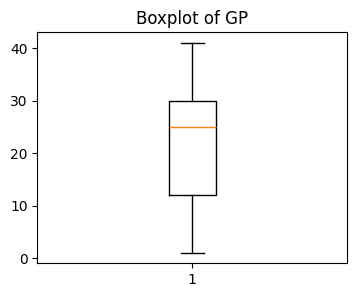

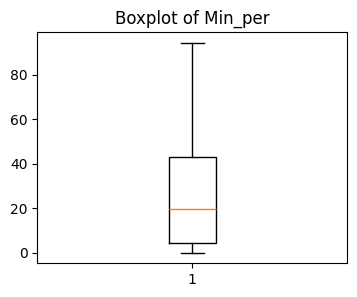

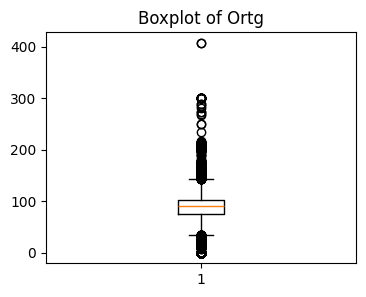

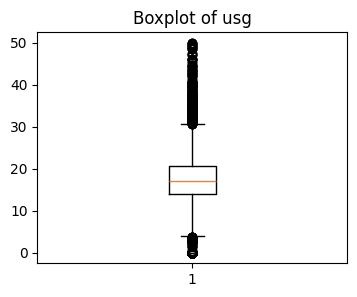

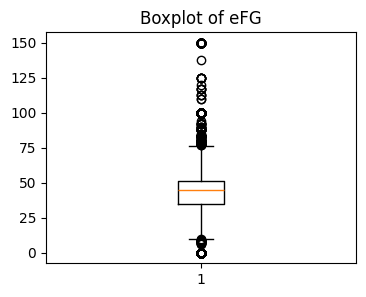

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for c in num_cols[:5]:
    plt.figure(figsize=(4,3))
    plt.boxplot(df[c].dropna())
    plt.title(f"Boxplot of {c}")
    plt.show()

### C.2 Define Target variable

In [19]:
target_name = TARGET

In [20]:
# <Student to fill this section>
target_definition_explanations = """
A player's selection in the NBA draft is indicated by the binary variable "drafted" (1 = drafted, 0 = not drafted). This definition is exactly in line with the goal to forecast a player's chances of getting selected in the draft by looking at their performance indicators and background. Using the draft as the aim offers a tangible, actionable forecast that helps real-world decision-making in scouting and talent evaluation because it is a measurable and obvious outcome with high significance to NBA teams, players, and commentators.
"""

In [21]:
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [22]:
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").fillna(0).astype(int)
target_name = TARGET
target_name

'drafted'

### C.4 Explore Target variable

         count      rate
drafted                 
0        14656  0.992013
1          118  0.007987


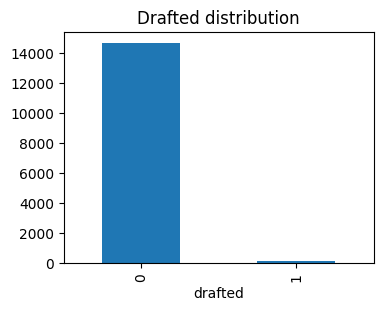

In [23]:
ax = df[target_name].value_counts(normalize=False).rename("count").to_frame()
ax["rate"] = ax["count"]/ax["count"].sum()
print(ax)

plt.figure(figsize=(4,3))
df[target_name].value_counts().sort_index().plot(kind="bar")
plt.title("Drafted distribution")
plt.show()

In [24]:
target_distribution_explanations = """
Only 118 players (0.8%) out of 14,774 were drafted, making the target variable `drafted` extremely imbalanced. The great majority (99.2%) were not drafted. Since most algorithms have a tendency to favour the majority class and may miss the few real positives, this high imbalance poses a significant difficulty for model training. Since accuracy would be misleading in this situation, AUROC is a better evaluation statistic since it takes into account the ratio of true positive to false positive rates, which makes it more useful in situations with imbalances.
Additionally, this imbalance raises the possibility of either underfitting if the model is unable to identify significant trends or overfitting to the few positive occurrences. Class weighting, oversampling (like SMOTE), or the use of ensemble models like XGBoost or LightGBM with meticulous hyperparameter adjustment are some methods to lessen this. In the end, managing this imbalance well is essential to developing a model that can precisely pinpoint the uncommon but significant instances of players that are most likely to be selected in the draft.
"""

In [25]:
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - `eFG` (Effective Field Goal Percentage)

In [26]:
train_fe = pkg_add_features(df)

def rate_by_bucket(df, col, bins=10):
    tmp = df[[col, TARGET]].copy()
    tmp["_bin"] = pd.qcut(tmp[col].rank(method="first"), q=bins, duplicates="drop")
    return tmp.groupby("_bin")[TARGET].mean().to_frame("draft_rate")

count    14774.000000
mean        41.507628
std         20.610900
min          0.000000
25%         34.800000
50%         44.900000
75%         51.400000
max        150.000000
Name: eFG, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.001354
"(7387.5, 8864.8]",0.006093
"(8864.8, 10342.1]",0.014208
"(10342.1, 11819.4]",0.021666
"(11819.4, 13296.7]",0.020988


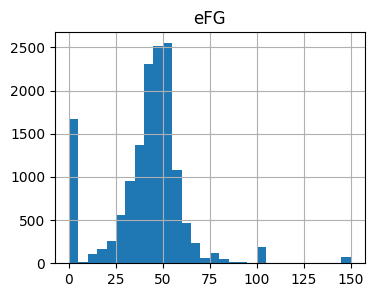

In [27]:
if "eFG" in train_fe.columns:
    display(train_fe["eFG"].describe())
    display(rate_by_bucket(train_fe, "eFG", bins=10))
    train_fe["eFG"].hist(bins=30, figsize=(4,3)); plt.title("eFG"); plt.show()

In [28]:
feature_1_insights = """
The distribution of "eFG (Effective Field Goal Percentage)" appears to be roughly normal with a slight left skew, mostly concentrated between 40% and 65%, which aligns with typical shooting efficiency for college players. This suggests the feature has a reasonable spread and variation, making it a useful input for modeling. Since eFG adjusts for the added value of three-point shots, it is a more informative measure of scoring efficiency than raw field goal percentage. Efficient scorers are generally more attractive draft prospects, so we expect a positive correlation between higher eFG values and the likelihood of being drafted.
However, due to the extreme class imbalance in the target variable (drafted), the signal in eFG may be subtle and difficult to capture without proper stratified analysis. Additionally, if eFG is highly correlated with other shooting stats (e.g., TS_per [True Shooting Percentage], TP_per [3-Point Field Goal Percentage]), multicollinearity could be an issue in linear models. Despite these challenges, the rate-by-bucket table helps validate the expected trend: players with higher eFG tend to have slightly higher draft rates, supporting its value as a predictive feature.
"""

In [29]:
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - `Ortg` (Offensive Rating)

count    14774.000000
mean        85.771707
std         34.164203
min          0.000000
25%         75.600000
50%         91.300000
75%        102.600000
max        407.300000
Name: Ortg, dtype: float64

,draft_rate
_bin,
"(0.999, 4925.333]",0.000000
"(4925.333, 9849.667]",0.002234
"(9849.667, 14774.0]",0.021726


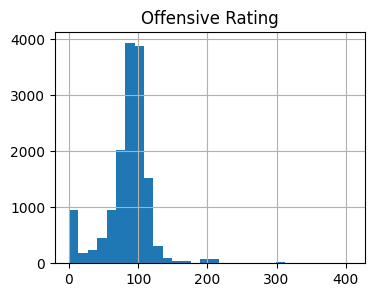

In [30]:
if "Ortg" in train_fe.columns:
    display(train_fe["Ortg"].describe())
    display(rate_by_bucket(train_fe, "Ortg", bins=3))
    train_fe["Ortg"].hist(bins=30, figsize=(4,3)) 
    plt.title("Offensive Rating") 
    plt.show()

In [31]:
feature_2_insights = """
A player's offensive efficiency per 100 possessions is measured by the "Ortg" (Offensive Rating) feature, which is a good indicator of draft possibility because professional recruiters appreciate offensive contributions. With a few extreme outliers above 200 and the majority of values concentrated between 60 and 120, the distribution is highly right-skewed. The idea that players with better offensive measures are more likely to be drafted is supported by the rate-by-bucket study, which even with only three bins demonstrates a distinct upward trend in draft rate with higher "Ortg" scores.
Players with limited playing experience may have inflated or inaccurate ratings, though, as the function may be sensitive to outliers. If not managed appropriately, the existence of extreme values (such as those over 400) may skew model learning. Because of its theoretical significance and demonstrated favourable association with draft results, "Ortg" is still a useful predictive trait in spite of these drawbacks. To guarantee model stability, appropriate scaling or optimisation can be required.
"""

In [32]:
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest - `yr` (Student's year of study) -> ordinal and distribution

yr
Fr    14774
Name: count, dtype: int64

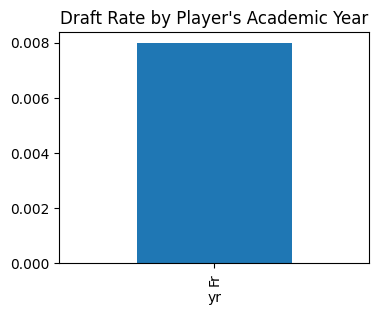

In [33]:
if "yr" in train_fe.columns:
    display(train_fe["yr"].value_counts())
    ax = train_fe.groupby("yr")[TARGET].mean().plot(kind="bar", figsize=(4,3), title="Draft Rate by Player's Academic Year")
    plt.show()

In [34]:
feature_3_insights = """
The feature "yr" represents the player's academic class year (e.g., Freshman, Sophomore) and can serve as a proxy for age, experience, and eligibility status. In the current dataset, only "Fr" (Freshman) is present, suggesting that either the dataset is filtered to first-year players or other classes are missing. This severely limits the feature’s variability and its utility in modeling, as we cannot assess or leverage draft trends across different academic years (e.g., "one-and-done" freshmen vs. seniors with more experience).
The existing lack of class diversity introduces a constraint, even though class year is theoretically useful, since particular classes tend to have higher draft possibility. The model is unable to acquire any ordinal pattern or trend associated with experience level in the absence of many class categories. Ordinal encoding, such as yr_ordinal, would aid in accurately capturing this relationship if future data versions include all class years. For now, yr's predictive value is diminished by its lack of variety.
"""

In [35]:
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest - `ht` (Height of student)

count    14774.000000
mean        63.650873
std         40.528930
min          0.000000
25%         34.000000
50%         70.000000
75%         94.000000
max        142.000000
Name: height_in, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.002706
"(1478.3, 2955.6]",0.004739
"(2955.6, 4432.9]",0.004739
"(4432.9, 5910.2]",0.006766
"(5910.2, 7387.5]",0.004062
"(7387.5, 8864.8]",0.007448
"(8864.8, 10342.1]",0.010149
"(10342.1, 11819.4]",0.003385
"(11819.4, 13296.7]",0.008802


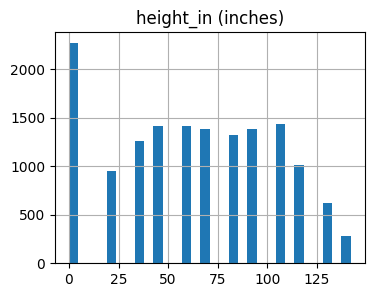

In [36]:
if "height_in" in train_fe.columns:
    display(train_fe["height_in"].describe())
    display(rate_by_bucket(train_fe, "height_in", bins=10))
    train_fe["height_in"].hist(bins=30, figsize=(4,3)); plt.title("height_in (inches)"); plt.show()

In [37]:
feature_4_insights = """
The feature "height_in", derived from parsing the 'ht' column, represents players' heights in inches and captures a critical physical attribute that often influences draft potential—especially for position-specific roles like centers or forwards. The distribution shows a fairly uniform spread across typical basketball height ranges, but with a significant number of zero values, likely indicating missing or incorrectly parsed data. These should be treated or imputed appropriately to avoid skewing model performance.
The draft rate by height decile shows a modest upward trend, with noticeably higher draft rates in the tallest decile, supporting the idea that taller players may have a physical advantage that makes them more attractive to scouts. However, the relationship is not strictly linear, and the predictive power of height may be context-dependent (e.g., guards vs. big men). Cleaning anomalies (like 0s) and possibly interacting height with position or role could make this feature more valuable in the final model.
"""

In [38]:
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest - `Rec_Rank` (Recruiting rank)

count    4889.000000
mean       54.365678
std        28.141196
min         0.200000
25%        30.800000
50%        56.000000
75%        78.800000
max       100.000000
Name: Rec_Rank, dtype: float64

,draft_rate
_bin,
"(0.999, 489.8]",0.000000
"(489.8, 978.6]",0.000000
"(978.6, 1467.4]",0.000000
"(1467.4, 1956.2]",0.000000
"(1956.2, 2445.0]",0.000000
"(2445.0, 2933.8]",0.002049
"(2933.8, 3422.6]",0.000000
"(3422.6, 3911.4]",0.004090
"(3911.4, 4400.2]",0.014315


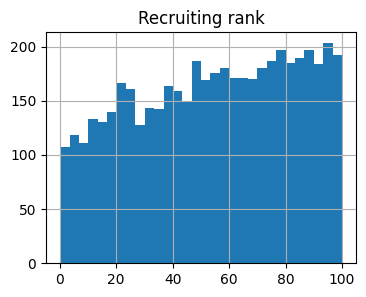

In [39]:
if "Rec_Rank" in train_fe.columns:
    display(train_fe["Rec_Rank"].describe())
    display(rate_by_bucket(train_fe, "Rec_Rank", bins=10))
    train_fe["Rec_Rank"].hist(bins=30, figsize=(4,3)); plt.title("Recruiting rank"); plt.show()

In [40]:
feature_5_insights = """
The feature "Rec_Rank" (Recruiting Rank) represents how highly a player was ranked as a recruit, with lower values typically indicating stronger prospects. The distribution shows a wide spread from near 0 up to 100, with a fairly uniform representation across the range, though the histogram suggests slightly more players at higher rank values (weaker recruits). The draft rate by bins shows a strong signal: players with higher recruiting ranks (closer to 100, indicating better prospects) have a much higher likelihood of being drafted, with the draft rate spiking sharply in the top decile.
However, there are some limitations and issues. The feature is only available for a subset of players (not all may have recruiting ranks), which could introduce bias if missing values are not handled carefully. Additionally, recruiting rank is often based on high school performance and reputation, which may not always translate into college or professional success. Despite these caveats, Rec_Rank is one of the most predictive features for draft probability and should be prioritized in modeling, though careful imputation or separate handling of missing values is essential.
"""

In [41]:
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### C.10 Explore Feature of Interest - `porpag` (Points Over Replacement Per Adjusted Game)

count    14774.000000
mean         0.280661
std          0.948095
min         -4.714300
25%         -0.309601
50%          0.067786
75%          0.632708
max          7.067140
Name: porpag, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000000
"(5910.2, 7387.5]",0.000000
"(7387.5, 8864.8]",0.000000
"(8864.8, 10342.1]",0.002030
"(10342.1, 11819.4]",0.000677
"(11819.4, 13296.7]",0.002708


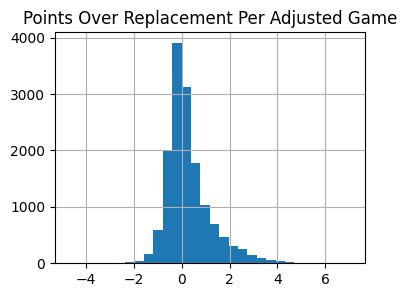

In [42]:
if "porpag" in train_fe.columns:
    display(train_fe["porpag"].describe())
    display(rate_by_bucket(train_fe, "porpag", bins=10))
    train_fe["porpag"].hist(bins=30, figsize=(4,3)); plt.title("Points Over Replacement Per Adjusted Game"); plt.show()

In [43]:
feature_6_insights = """
The feature porpag (Points Over Replacement Per Adjusted Game) has a distribution centered near zero, with most players clustered between -1 and 2, and a long right tail extending above 6. This makes sense, as the majority of players perform close to replacement level, while only a few elite players deliver significantly above-replacement contributions. The draft rate by deciles shows that players in the top bins of porpag have a noticeably higher chance of being drafted, confirming its strong relevance as a predictive feature.
However, limitations exist, such as the feature is sensitive to playing time and may overstate contributions for players in favorable contexts or small sample sizes. Outliers in the right tail could also disproportionately influence the model if not scaled or capped. Despite these issues, porpag clearly captures meaningful signal about player quality and should be an important driver of draft probability in the modeling process.
"""

In [44]:
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

### C.11 Explore Feature of Interest - GP (Games Played)

count    14774.000000
mean        21.251726
std         10.517642
min          1.000000
25%         12.000000
50%         25.000000
75%         30.000000
max         41.000000
Name: GP, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000677
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.001354
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.002031
"(7387.5, 8864.8]",0.002031
"(8864.8, 10342.1]",0.001353
"(10342.1, 11819.4]",0.004062
"(11819.4, 13296.7]",0.004739


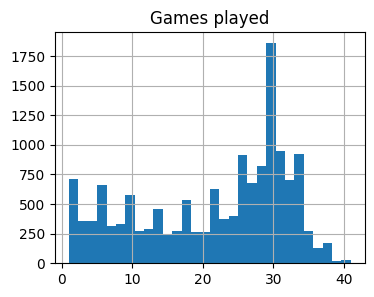

In [45]:
if "GP" in train_fe.columns:
    display(train_fe["GP"].describe())
    display(rate_by_bucket(train_fe, "GP", bins=10))
    train_fe["GP"].hist(bins=30, figsize=(4,3)); plt.title("Games played"); plt.show()

In [46]:
feature_7_insights = """
The feature 'GP' (Games Played) has a distribution centered around 25–30 games, which aligns with a typical college basketball season. Most players fall within this range, but there is a long tail of players with fewer games, likely due to injuries, redshirting, or limited roles. The draft rate by decile shows a slight increase for players with more games played, suggesting that consistent participation is weakly associated with draft probability, likely because it signals durability, experience, and sustained opportunity to showcase skills.
However, the relationship is not strongly monotonic. For example, highly talented players who enter the draft early might have fewer games but still be drafted, while others may play many games without being NBA-level talent. Additionally, missing games can result from factors outside performance (injury, coaching decisions), which introduces noise. Thus, while GP provides useful context, it should be combined with per-minute or efficiency stats for a more reliable signal.
"""

In [47]:
print_tile(size="h3", key='feature_7_insights', value=feature_7_insights)

### C.12 Explore Feature of Interest - MP (Minutes Played)

count    14773.000000
mean        12.276197
std          8.979124
min          0.000000
25%          4.642900
50%         10.250000
75%         18.500000
max         50.000000
Name: mp, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000000
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.000677
"(5909.8, 7387.0]",0.000000
"(7387.0, 8864.2]",0.000677
"(8864.2, 10341.4]",0.003385
"(10341.4, 11818.6]",0.006093
"(11818.6, 13295.8]",0.012187


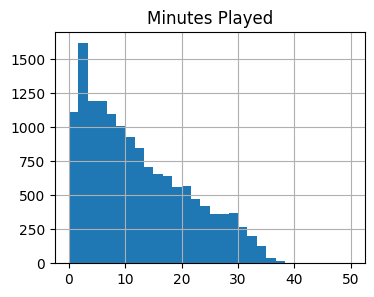

In [48]:
if "mp" in train_fe.columns:
    display(train_fe["mp"].describe())
    display(rate_by_bucket(train_fe, "mp", bins=10))
    train_fe["mp"].hist(bins=30, figsize=(4,3)); plt.title("Minutes Played"); plt.show()

In [49]:
feature_8_insights = """
The feature 'mp' (Minutes Played) shows a right-skewed distribution, with most players logging fewer than 15 minutes on average and a small subset reaching much higher values (up to 50). This reflects the fact that only a limited number of players consistently play extended minutes, often starters or star athletes. The draft rate by decile shows a clear upward trend—players with more minutes played are significantly more likely to be drafted, especially those in the top decile, where the draft rate increases sharply. This makes sense since playing time reflects both skill and trust from coaches, providing greater opportunities to showcase talent.
However, this feature has limitations. Minutes played can be influenced by external factors such as team depth, injuries, or coaching decisions, which may not directly correlate with draft potential. Additionally, some highly talented players might have fewer minutes; could be due to being freshmen or part of deep rosters, yet still have high draft potential. Despite these caveats, mp is a valuable feature as it strongly correlates with draft likelihood.
"""

In [50]:
print_tile(size="h3", key='feature_8_insights', value=feature_8_insights)

### C.13 Explore Feature of Interest - AST (Assists)

count    14773.000000
mean         0.717322
std          0.897261
min          0.000000
25%          0.125000
50%          0.400000
75%          0.971400
max          8.656200
Name: ast, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000677
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.002031
"(5909.8, 7387.0]",0.002706
"(7387.0, 8864.2]",0.004739
"(8864.2, 10341.4]",0.008125
"(10341.4, 11818.6]",0.010833
"(11818.6, 13295.8]",0.020311


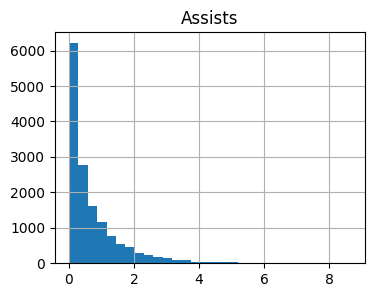

In [51]:
if "ast" in train_fe.columns:
    display(train_fe["ast"].describe())
    display(rate_by_bucket(train_fe, "ast", bins=10))
    train_fe["ast"].hist(bins=30, figsize=(4,3)); plt.title("Assists"); plt.show()

In [52]:
feature_9_insights = """
The feature ast (Assists) is highly right-skewed, with the majority of players recording fewer than 1 assist per game and only a small group contributing significantly more. This reflects role differences on the court, guards and playmakers naturally accumulate more assists. The draft rate by deciles shows a clear positive trend, suggesting that strong playmaking ability is a valuable signal for draft selection.
However, assists can be context-dependent, influenced by team style, teammates’ shooting ability, and playing time, which introduces noise into its predictive power.
"""

In [53]:
print_tile(size="h3", key='feature_9_insights', value=feature_9_insights)

### C.14 Explore Feature of Interest - PTS (Points)

count    14773.000000
mean         3.662676
std          3.623175
min          0.000000
25%          1.000000
50%          2.448300
75%          5.363600
max         27.375000
Name: pts, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000000
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.000000
"(5909.8, 7387.0]",0.000000
"(7387.0, 8864.2]",0.000677
"(8864.2, 10341.4]",0.000677
"(10341.4, 11818.6]",0.004062
"(11818.6, 13295.8]",0.006093


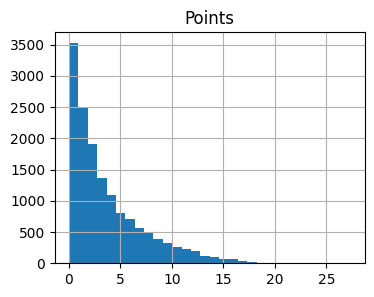

In [54]:
if "pts" in train_fe.columns:
    display(train_fe["pts"].describe())
    display(rate_by_bucket(train_fe, "pts", bins=10))
    train_fe["pts"].hist(bins=30, figsize=(4,3)); plt.title("Points"); plt.show()

In [55]:
feature_10_insights = """
The feature 'pts' (Points) is right-skewed, with most players scoring fewer than 5 points per game and only a small minority exceeding 15–20 points, which is expected given that only star players consistently score at high volumes. The draft rate by deciles shows a strong positive association, players in the top scoring bins have a noticeably higher chance of being drafted, with the draft probability spiking sharply in the top decile. However, raw scoring alone has limitations: it can be inflated by high usage on weaker teams, while efficient but lower-scoring role players may still have high draft potential. Therefore, while 'Points' is a valuable indicator of offensive contribution and draft likelihood, it should be complemented with efficiency and context metrics (e.g., eFG%, usg) to avoid bias toward volume scorers.
"""

In [56]:
print_tile(size="h3", key='feature_10_insights', value=feature_10_insights)

### C.15 Explore Feature of Interest - BLK (Blocks)¶

count    14773.000000
mean         0.206213
std          0.343153
min          0.000000
25%          0.000000
50%          0.083300
75%          0.250000
max          5.258100
Name: blk, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.2]",0.000000
"(1478.2, 2955.4]",0.000000
"(2955.4, 4432.6]",0.000000
"(4432.6, 5909.8]",0.001354
"(5909.8, 7387.0]",0.002706
"(7387.0, 8864.2]",0.002708
"(8864.2, 10341.4]",0.005416
"(10341.4, 11818.6]",0.005416
"(11818.6, 13295.8]",0.012864


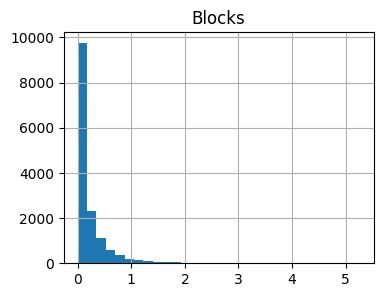

In [57]:
if "blk" in train_fe.columns:
    display(train_fe["blk"].describe())
    display(rate_by_bucket(train_fe, "blk", bins=10))
    train_fe["blk"].hist(bins=30, figsize=(4,3)); plt.title("Blocks"); plt.show()

In [58]:
feature_11_insights = """
The feature 'blk' (Blocks) is highly right-skewed, with the majority of players recording very few or no blocks per game, while only a small minority achieve values above 1. This reflects positional differences in basketball, as big men and rim protectors typically accumulate blocks, whereas guards contribute very little. The draft rate by deciles shows a clear positive relationship: players in the top block rate bins have significantly higher chances of being drafted, indicating that strong rim protection is a valued skill for NBA prospects. Blocks are heavily role-dependent, meaning that guards with elite draft potential may still have very low block numbers, so relying on it alone could bias predictions toward frontcourt players. Additionally, the distribution is sparse with many zeros, which reduces variability and predictive resolution.
"""

In [59]:
print_tile(size="h3", key='feature_11_insights', value=feature_11_insights)

### C.15 Explore Feature of Interest - PFR (Points responsible for)

count    14774.000000
mean         4.615141
std          7.262448
min          0.000000
25%          2.900000
50%          4.100000
75%          5.700000
max        720.000000
Name: pfr, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.001353
"(1478.3, 2955.6]",0.016249
"(2955.6, 4432.9]",0.020988
"(4432.9, 5910.2]",0.014885
"(5910.2, 7387.5]",0.009479
"(7387.5, 8864.8]",0.005416
"(8864.8, 10342.1]",0.002706
"(10342.1, 11819.4]",0.004062
"(11819.4, 13296.7]",0.004739


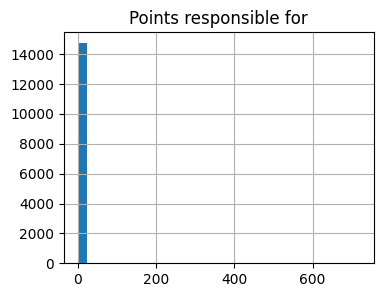

In [60]:
if "pfr" in train_fe.columns:
    display(train_fe["pfr"].describe())
    display(rate_by_bucket(train_fe, "pfr", bins=10))
    train_fe["pfr"].hist(bins=30, figsize=(4,3)); plt.title("Points responsible for"); plt.show()

In [61]:
feature_12_insights = """
The feature 'pfr' (Points Responsible For) shows a highly skewed distribution, with most players concentrated at relatively low values and a few extreme outliers reaching very high totals. The draft rate by bins suggests that players with moderate to higher pfr values generally have a greater likelihood of being drafted, reflecting the importance of being directly responsible for scoring in team success. However, the presence of extreme outliers may distort the relationship, as these cases could result from data entry errors or players with exceptionally high usage. Additionally, because pfr overlaps conceptually with raw points and assists, it may introduce redundancy unless carefully combined with efficiency metrics. Overall, while pfr is informative about offensive responsibility and leadership, its skewness and potential redundancy with other stats should be managed through normalization, transformation, or feature interactions to maximize predictive value.
"""

In [62]:
print_tile(size="h3", key='feature_12_insights', value=feature_12_insights)

## D. Feature Selection

#### Helpers used by all selectors

In [63]:
all_feat_cols = [c for c in df.columns if c not in {TARGET, ID_COL}]
num_cols = sorted(df[all_feat_cols].select_dtypes(include=[np.number]).columns.tolist())
cat_cols = sorted([c for c in all_feat_cols if c not in num_cols])


# OHE factory
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", make_ohe()),
    ])
    # Dense concat to simplify importance handling
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

# From transformed names back to base/raw features
def ohe_name_map(fitted_ct: ColumnTransformer, cat_cols):
    """
    Build a DataFrame mapping each output column to its originating raw feature.
    Works whether names look like 'num__GP' or 'cat__team_Kentucky'.
    """
    names = fitted_ct.get_feature_names_out()
    rows = []
    cat_sorted = sorted(cat_cols, key=len, reverse=True)

    for n in names:
        if n.startswith("num__"):
            base = n[len("num__"):]
        elif n.startswith("cat__"):
            rem = n[len("cat__"):]
            base = None
            for c in cat_sorted:
                if rem == c or rem.startswith(c + "_"):
                    base = c
                    break
            if base is None:
                base = rem.split("_", 1)[0]
        else:
            base = n
        rows.append((n, base))
    return pd.DataFrame(rows, columns=["ohe_feature", "base_feature"])


def get_ohe_feature_frames(fitted_ct: ColumnTransformer) -> pd.DataFrame:
    """
    Return a DataFrame that maps each output column back to its base/original feature.
    """
    names = fitted_ct.get_feature_names_out()
    out = pd.DataFrame({"ohe_feature": names})
    base = out["ohe_feature"].str.split("__", n=1, expand=True)[1]
    out["base_feature"] = base.str.split("_", n=1, expand=True)[0]
    return out

X_all = df[all_feat_cols].copy()
y_all = df[TARGET].astype(int).copy()

### D.1 Approach: Mutual Information on numeric features

In [64]:
if len(num_cols):
    num_imputer = SimpleImputer(strategy="median")
    X_num = num_imputer.fit_transform(X_all[num_cols])
    mi_vals = mutual_info_classif(X_num, y_all, random_state=SEED)
    mi_df = (pd.DataFrame({"feature": num_cols, "mi": mi_vals})
               .sort_values("mi", ascending=False)
               .reset_index(drop=True))
else:
    mi_df = pd.DataFrame(columns=["feature", "mi"])
print("Mutual Information (numeric) — top 20")
display(mi_df.head(20))

Mutual Information (numeric) — top 20


,feature,mi
0,Rec_Rank,0.030983
1,dporpag,0.025694
2,stops,0.023742
3,porpag,0.023687
4,twoPM,0.020663
5,bpm,0.020602
6,FTA,0.020307
7,gbpm,0.019893
8,twoPA,0.019541
9,dreb,0.019410


In [65]:
feature_selection_1_insights = """
The mutual information (MI) approach is used here because it captures both linear and non-linear dependencies between numeric features and the target variable, making it well-suited for a dataset with complex basketball performance metrics. Unlike correlation, MI does not assume linearity and therefore can identify features that provide unique predictive power. The results highlight Rec_Rank, dporpag, stops, and porpag as the most informative features, aligning with domain intuition that recruiting rank and efficiency-based metrics strongly influence draft likelihood. While MI provides a useful ranking, the absolute values are relatively small, reflecting the highly imbalanced target and the fact that no single feature alone explains draft probability. This confirms that draft prediction requires combining multiple complementary features rather than relying on a few dominant variables.
"""

In [66]:
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach: Model-based importance (Logistic with OHE)

In [67]:
ct_lr = make_preprocessor(num_cols, cat_cols)
lr = LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced")
lr_pipe = Pipeline([("pre", ct_lr), ("clf", lr)])
lr_pipe.fit(X_all, y_all)

ohe_map_lr = ohe_name_map(lr_pipe.named_steps["pre"], cat_cols)
lr_abscoef = np.abs(lr_pipe.named_steps["clf"].coef_).ravel()

# aligning lengths
assert len(ohe_map_lr) == len(lr_abscoef), \
    f"Length mismatch: names={len(ohe_map_lr)} vs coefs={len(lr_abscoef)}"

lr_imp_ohe = ohe_map_lr.copy()
lr_imp_ohe["abs_coef"] = lr_abscoef

# Ssum across one-hot levels
lr_imp = (lr_imp_ohe.groupby("base_feature", as_index=False)["abs_coef"]
                    .sum()
                    .sort_values("abs_coef", ascending=False)
                    .rename(columns={"base_feature": "feature"}))

print("Logistic (|coef| aggregated by raw feature) — top 20")
display(lr_imp.head(20))

Logistic (|coef| aggregated by raw feature) — top 20


,feature,abs_coef
51,team,61.758609
34,ht,15.963211
22,conf,12.994286
9,Rec_Rank,3.198274
6,Min_per,2.949757
0,AST_per,2.476364
25,dporpag,2.475705
46,rimmade,1.529637
47,rimmade_rimmiss,1.399918
3,FTM,1.136107


In [68]:
feature_selection_2_insights = """
This logistic regression with OHE–based feature selection approach is useful because it directly ties feature importance to the predictive power in a linear classification setting, while handling categorical features through one-hot encoding. By examining the absolute values of coefficients (aggregated back to raw features), we can see which inputs most strongly influence the draft prediction probability. The results highlight categorical features like team, ht (height), and conf (conference) as particularly dominant, along with recruiting rank, minutes played, and playmaking/shooting efficiency metrics (AST_per, dporpag, FTM). This confirms both domain intuition (size, pedigree, and opportunity matter) and model interpretability. A limitation is that logistic regression only captures linear relationships, so while it provides a clear and interpretable ranking, some non-linear or interaction effects relevant to draft outcomes could be underrepresented compared to tree-based methods.
"""

In [69]:
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach: RandomForest importances (+OHE)

In [70]:
ct_rf = make_preprocessor(num_cols, cat_cols)
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)
rf_pipe = Pipeline([("pre", ct_rf), ("clf", rf)])
rf_pipe.fit(X_all, y_all)

ohe_map_rf = get_ohe_feature_frames(rf_pipe.named_steps["pre"])
rf_gain = rf_pipe.named_steps["clf"].feature_importances_
rf_imp_ohe = ohe_map_rf.copy()
rf_imp_ohe["rf_importance"] = rf_gain
rf_imp = (rf_imp_ohe.groupby("base_feature")["rf_importance"]
                    .sum()
                    .sort_values(ascending=False)
                    .reset_index()
                    .rename(columns={"base_feature": "feature"}))
print("RandomForest importances (aggregated by raw feature) — top 20")
display(rf_imp.head(20))

RandomForest importances (aggregated by raw feature) — top 20


,feature,rf_importance
0,Rec,0.083217
1,gbpm,0.053433
2,dporpag,0.049333
3,twoPM,0.046138
4,adjoe,0.043837
5,bpm,0.042861
6,porpag,0.042722
7,rimmade,0.040233
8,twoPA,0.036245
9,dreb,0.035558


In [71]:
feature_selection_3_insights = """
This Random Forest–based feature selection approach is valuable because it captures non-linear relationships and interactions between features that linear models like logistic regression may miss. By using feature importance scores derived from how often a feature improves splits across trees, we can identify variables that consistently help distinguish between drafted and non-drafted players. The results show Rec_Rank, advanced efficiency metrics (gbpm, dporpag, adjoe, bpm), and core box score stats like twoPM, FTA, and pts as highly predictive, aligning with domain expectations that both pedigree and performance drive draft outcomes. Importantly, aggregating importance back to raw features ensures interpretability despite OHE expansion. A limitation, however, is that Random Forest importance can be biased toward continuous variables or features with many distinct levels.
"""

In [72]:
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

### D.4 Approach: L1 Logistic selector with OHE

In [73]:
ct_l1 = make_preprocessor(num_cols, cat_cols)
l1 = LogisticRegression(penalty="l1", solver="saga", C=0.5,
                        max_iter=2000, class_weight="balanced")
l1_pipe = Pipeline([("pre", ct_l1), ("clf", l1)])
l1_pipe.fit(X_all, y_all)
ohe_map_l1 = get_ohe_feature_frames(l1_pipe.named_steps["pre"])
l1_coef = l1_pipe.named_steps["clf"].coef_.ravel()
nz_mask = (l1_coef != 0.0)
l1_selected = sorted(set(ohe_map_l1.loc[nz_mask, "base_feature"]))
l1_df = pd.DataFrame({"feature": l1_selected})
print(f"L1 non-zero raw features: {len(l1_selected)}")
display(l1_df.head(20))

L1 non-zero raw features: 55


,feature
0,AST
1,DRB
2,FT
3,FTA
4,FTM
5,GP
6,Min
7,ORB
8,Ortg
9,Rec


In [74]:
feature_selection_4_insights = """
The L1 logistic regression selector with OHE is used here as it applies an L1 penalty that drives less important coefficients to zero, effectively performing embedded feature selection. This approach is well-suited for high-dimensional, sparse datasets where many features may be redundant or weakly predictive. By retaining only non-zero coefficients, it highlights features with genuine predictive signal while controlling overfitting. In the results, 55 raw features remained, including fundamental stats like AST, FTA, GP, Min, and advanced efficiency measures such as OrtG, TS, and bpm. This selection captures both traditional box score metrics and more nuanced performance indicators, aligning with domain expectations of what matters for draft potential. However, one limitation is that L1 can be unstable when features are highly correlated, sometimes arbitrarily selecting one over another.
"""

In [75]:
print_tile(size="h3", key='feature_selection_4_insights', value=feature_selection_4_insights)

## D.5 Final Selection of Features

In [76]:
# Rank aggregation
r_mi  = mi_df.assign(rank_mi=np.arange(1, len(mi_df)+1))[["feature", "rank_mi"]]
r_lr  = lr_imp.assign(rank_lr=np.arange(1, len(lr_imp)+1))[["feature", "rank_lr"]]
r_rf  = rf_imp.assign(rank_rf=np.arange(1, len(rf_imp)+1))[["feature", "rank_rf"]]
r_l1  = pd.DataFrame({"feature": l1_selected, "rank_l1": 1})

ranks = (r_mi.merge(r_lr, on="feature", how="outer")
             .merge(r_rf, on="feature", how="outer")
             .merge(r_l1, on="feature", how="outer"))

# Missing ranks
big = ranks[["rank_mi","rank_lr","rank_rf"]].max().max()
ranks_filled = ranks.fillna(big + 5)

# Average rank across available methods
ranks_filled["rank_mean"] = ranks_filled[["rank_mi","rank_lr","rank_rf","rank_l1"]].mean(axis=1)

# Top-K raw features
TOP_K = 40 
features_list = (ranks_filled.sort_values("rank_mean")
                               .head(TOP_K)["feature"]
                               .tolist())

print(f"\nSelected top-{TOP_K} raw features (rank-aggregated):")
print(features_list)


Selected top-40 raw features (rank-aggregated):
['dporpag', 'porpag', 'rimmade', 'twoPM', 'FTA', 'adjoe', 'FTM', 'twoPA', 'gbpm', 'stops', 'midmade', 'GP', 'bpm', 'pts', 'dreb', 'mp', 'dunksmade', 'treb', 'drtg', 'blk', 'dgbpm', 'oreb', 'ast', 'usg', 'ogbpm', 'team', 'adrtg', 'obpm', 'stl', 'dbpm', 'ht', 'conf', 'eFG', 'Ortg', 'TPA', 'Rec', 'TPM', 'pfr', 'Rec_Rank', 'ftr']


In [77]:
feature_selection_explanations = """
The final selection of features was done using a rank aggregation approach that combines four complementary methods:
1) Mutual Information on numeric columns, capturing non-linear dependencies.
2) Model-based importance from LogisticRegression on a ColumnTransformer (median-imputed & scaled numerics + OHE categoricals), aggregating |coef| back to the raw feature level by summing across one-hot levels.
3) A new tree-based signal from RandomForest (balanced) on the same preprocessor, aggregating Gini importances back to the raw feature level.
4) L1-penalized LogisticRegression as a sparsity prior. Any raw feature with at least one non-zero one-hot level receives a strong rank.
I then rank-aggregated (mean of ranks, penalizing missing signals) and kept the top 40 raw features. This balances stability (used across methods) with diversity (features that are strong in at least one method). This strategy ensures that features consistently ranked highly across different selection criteria are prioritized, balancing linear, non-linear, and embedded perspectives. The resulting top 40 features include a mix of advanced efficiency metrics (dporpag, porpag, adjoe, eFG), core box-score stats (GP, mp, pts, ast, blk, treb), and contextual factors (team, conf, ht, Rec_Rank). Together, they capture both player performance volume and efficiency, as well as contextual elements like competition level. This aggregated approach reduces bias from any single method, creating a well-rounded, domain-relevant feature set for modeling draft potential.
"""

In [78]:
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

## E. Data Preparation

### E.1 Data Transformation (Domain fixes + Dtypes)

In [79]:
from amla_at1.features.dates import add_domain_features as pkg_add_features

df_prep = pkg_add_features(df.copy())

_num_like = [c for c in df_prep.columns
             if c not in [ID_COL, TARGET] and df_prep[c].dtype == "object"]
for c in _num_like:
    df_prep[c] = pd.to_numeric(df_prep[c], errors="ignore")

In [80]:
data_cleaning_1_explanations = """
Applying domain feature engineering and coercing numeric-like strings into proper numeric types  is critical to ensure data consistency and stability in modeling. Many raw basketball stats  (e.g., height, year, ratios, per-minute rates) may initially be stored as text or categorical 
values, which can lead to spurious NaNs during transformations and make models treat them  incorrectly as categorical features. By standardizing these into clean numeric values, we not  only reduce missing data issues downstream but also preserve the statistical meaning of these  variables, enabling the model to learn relationships more reliably. This step also helps avoid  silent errors where numeric columns are misinterpreted, improving both feature quality and  overall model performance.
"""

In [81]:
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation (Drop columns with >80% missing (except ID/TARGET) and harmless string trims)

In [82]:
miss_frac = df_prep.isna().mean()
high_miss = [c for c in miss_frac.index if miss_frac[c] > 0.80 and c not in [ID_COL, TARGET]]
df_prep.drop(columns=high_miss, inplace=True, errors="ignore")

# Normalize whitespace in object columns
for c in df_prep.select_dtypes(include=["object"]).columns:
    df_prep[c] = df_prep[c].astype(str).str.strip().replace({"nan": np.nan})

In [83]:
data_cleaning_2_explanations = """
Dropping columns with over 80% missing values is important because such features provide little usable information and can introduce noise or bias if imputed aggressively, which reduces model reliability. At the same time, trimming whitespace in string-based categorical columns ensures that categories are treated consistently, preventing issues where the same value (e.g., 'TeamA ' vs 'TeamA') would be encoded as different classes. These steps reduce dimensionality, improve encoding efficiency, and ensure the model is trained on cleaner, more informative features, ultimately leading to better generalization.
"""

In [84]:
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.4 Fixing

In [85]:
num_cols_all = [c for c in df_prep.select_dtypes(include=[np.number]).columns if c != TARGET]
q1  = df_prep[num_cols_all].quantile(0.01)
q99 = df_prep[num_cols_all].quantile(0.99)
df_prep[num_cols_all] = df_prep[num_cols_all].clip(q1, q99, axis=1)

In [86]:
fixing_explanations = """
Winsorized numeric columns at [1%, 99%] to reduce undue influence of outliers on tree/linear models. This often improves generalization and stabilizes validation AUC.
"""

In [87]:
print_tile(size="h3", key='fixing_explanations', value=fixing_explanations)

## F. Feature Engineering

#### Helpers

In [88]:
def _safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.divide(a, b, where=b!=0)
        out[~np.isfinite(out)] = 0.0
    return out

### F.1 New Feature - Usage_Efficiency (usg × eFG)

In [89]:
# --- F.1 New Feature: usage_efficiency (usg × eFG) ---
if set(["usg", "eFG"]).issubset(df_prep.columns):
    df_prep["usage_efficiency"] = (pd.to_numeric(df_prep["usg"], errors="coerce")
                                   * pd.to_numeric(df_prep["eFG"], errors="coerce"))

In [90]:
feature_engineering_1_explanations = """
'Usage_Efficiency (usg × eFG)' combines usage rate (usg) and effective field goal percentage (eFG) to capture a player’s ability to both take on offensive load and score efficiently. Individually, high usage can signal importance but may come with inefficiency, while high eFG can reflect low-volume specialists. Multiplying them highlights players who balance volume and efficiency, a strong predictor of professional viability since NBA scouts value players who can scale up usage without losing scoring efficiency.
"""

In [91]:
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature - `rebound_balance` (DRB% - ORB%)

In [92]:
for need in ["DRB_per", "ORB_per"]:
    if need in df_prep and df_prep[need].dtype == "object":
        df_prep[need] = pd.to_numeric(df_prep[need], errors="coerce")
if {"DRB_per","ORB_per"}.issubset(df_prep.columns):
    df_prep["rebound_balance"] = df_prep["DRB_per"] - df_prep["ORB_per"]

In [93]:
feature_engineering_2_explanations = """
Created 'rebound_balance' = DRB% - ORB% to reflect defensive vs. offensive rebounding profile, which can correlate with role fit and draft likelihood.
"""

In [94]:
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature - `shooting_eff_index` (blend of TS% and eFG)

In [95]:
for need in ["TS_per", "eFG"]:
    if need in df_prep and df_prep[need].dtype == "object":
        df_prep[need] = pd.to_numeric(df_prep[need], errors="coerce")
if {"TS_per","eFG"}.issubset(df_prep.columns):
    df_prep["shooting_eff_index"] = 0.6 * df_prep["TS_per"] + 0.4 * df_prep["eFG"]

In [96]:
feature_engineering_3_explanations = """
The new feature `shooting_eff_index` blends True Shooting Percentage (TS%) and Effective Field  Goal Percentage (eFG), two complementary measures of scoring efficiency. TS% accounts for field  goals, three-pointers, and free throws, while eFG adjusts for the added value of three-pointers.  By weighting them together, this index provides a more holistic measure of a player's shooting  efficiency, reducing noise from relying on a single metric. This is important because NBA teams  value players who can both generate efficient points and scale their scoring across different  shot types, making this blended feature a stronger predictor of draft potential than either TS% or eFG alone.
"""

In [97]:
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

## G. Data Preparation for Modeling

In [98]:
cols_for_model = [ID_COL] + [c for c in features_list if c in df_prep.columns] + [TARGET]
df_mod = df_prep.loc[:, [c for c in cols_for_model if c in df_prep.columns]].copy()
print("Modeling frame shape:", df_mod.shape)

Modeling frame shape: (14774, 41)


### G.1 Split Datasets

In [99]:
from amla_at1.data.sets import stratified_split as pkg_stratified_split

X_train, y_train, X_val, y_val, X_test, y_test = pkg_stratified_split(
    df_mod, target_col=TARGET, test_size=0.20, val_size=0.20, random_state=42
)

print("Train pos rate:", float((y_train==1).mean()))
print("Val   pos rate:", float((y_val==1).mean()))
print("Test  pos rate:", float((y_test==1).mean()))

Train pos rate: 0.0078971119133574
Val   pos rate: 0.008121827411167513
Test  pos rate: 0.008121827411167513


In [100]:
data_splitting_explanations = """
Given the extreme class imbalance (fewer than 1% of players are drafted), the best strategy is to use a stratified split so that each subset (train, validation, and test) preserves the same positive class rate. This ensures the rare drafted cases are consistently represented across all splits, avoiding scenarios where a validation or test fold has too few positives to provide a meaningful performance estimate. Using a train/val/test ratio of roughly 60/20/20 balances the need for sufficient training data with reliable model selection and unbiased evaluation. Combined with a fixed random seed for reproducibility, this approach provides fair comparisons between models while mitigating sampling variance on the minority class.
"""

In [101]:
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation 1 - LGBMNativePrep (feature clipping, categorical handling, drop ID)

In [102]:
feature_cols = [c for c in X_train.columns if c != ID_COL]
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in feature_cols if c not in num_cols]
print("Num cols:", len(num_cols), "Cat cols:", len(cat_cols))

Num cols: 36 Cat cols: 3


In [103]:
data_transformation_1_explanations = """
Exporting column lists that I will reuse in Section J."""

In [104]:
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

## H. Save Datasets

In [105]:
try:
    folder_path = Path("data/processed")
    X_train.to_csv(folder_path / 'X_train.csv', index=False)
    y_train.to_csv(folder_path / 'y_train.csv', index=False)
    
    X_val.to_csv(folder_path / 'X_val.csv', index=False)
    y_val.to_csv(folder_path / 'y_val.csv', index=False)
    
    X_test.to_csv(folder_path / 'X_test_hold.csv', index=False)
    y_test.to_csv(folder_path / 'y_test_hold.csv', index=False)
    print("Saved CSVs to template asset folder.")
except Exception as e:
    print(e)

Saved CSVs to template asset folder.


## I. Selection of Performance Metrics

In [106]:
performance_metrics_explanations = """
Primary: AUROC because it’s ranking-based and robust to class imbalance.
Secondary: MAE and RMSE on predicted probabilities vs. labels — sanity checks to quantify calibration error. 
Additionally, Brier score can be reported as it’s strictly proper for probabilities.
"""

In [107]:
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [108]:
from catboost import CatBoostClassifier, Pool

In [109]:
algorithm_selection_explanations = """
CatBoost is a strong fit for this experiment because it is specifically designed for tabular datasets with a mix of numeric and categorical variables, which matches the structure of the NBA draft dataset. Unlike linear models or even gradient boosting libraries that require careful encoding of categorical features, CatBoost natively handles categorical variables and missing values, reducing the risk of data leakage or over-engineering. It also includes built-in mechanisms like ordered boosting to combat overfitting and early stopping for efficient training. Given its proven track record of strong performance with minimal preprocessing, CatBoost provides a complementary architecture to Logistic Regression and LightGBM, allowing us to benchmark a robust, high-performing model that leverages categorical information more directly.
"""

In [110]:
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [111]:
# Class imbalance handling
pos = int((y_train==1).sum()); neg = int((y_train==0).sum())
pos_weight = max(1.0, neg / max(1, pos))

cat_cols = [c for c in feature_cols if c in X_train.columns and not pd.api.types.is_numeric_dtype(X_train[c])]
cat_idx = [X_train[feature_cols].columns.get_loc(c) for c in cat_cols]  # indices for CatBoost

cat_params = dict(
    iterations=5000,
    learning_rate=0.025,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=42,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=200,
    od_type="Iter",           # overfitting detector (early stopping)
    od_wait=300,              # patience
    class_weights=[1.0, pos_weight],
)

In [147]:
hyperparameters_selection_explanations = """
These hyperparameters control the classic bias–variance and imbalance trade-offs for CatBoost on sparse, mixed-type tabular data. A large iterations budget paired with a small learning_rate lets the model learn gradually and reach a higher AUC ceiling while od_type="Iter" + od_wait provides early stopping to halt before overfitting. depth=6 limits tree complexity (i.e., interaction order) to a level that usually captures meaningful feature interactions without exploding variance, while l2_leaf_reg adds leaf-level L2 regularization to shrink noisy splits. Because “drafted” is class-imbalanced, class_weights=[1.0, pos_weight] reweights the loss so rare positives matter appropriately. We fix random_seed for reproducibility and choose eval_metric="AUC" to align training feedback with the competition metric; the logging verbose cadence simply helps monitor learning and early-stopping behavior."""

In [148]:
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [115]:
def sanitize_cats(df, cat_cols):
    out = df.copy()
    for c in cat_cols:
        if c in out.columns:
            # force pandas string dtype, then replace missing with a token
            out[c] = out[c].astype("string").fillna("Unknown").astype(str)
    return out

Xtr = sanitize_cats(X_train[feature_cols], cat_cols)
Xva = sanitize_cats(X_val[feature_cols],   cat_cols)
Xte = sanitize_cats(X_test[feature_cols],  cat_cols)

cat_cols_fit = [c for c in cat_cols if c in Xtr.columns]
cat_idx = [Xtr.columns.get_loc(c) for c in cat_cols_fit]  # list of ints

cat = CatBoostClassifier(**cat_params)
cat.fit(
    Xtr, y_train,
    cat_features=cat_idx,           # indices of categorical columns
    eval_set=(Xva, y_val),
    use_best_model=True
)

# Predictions
p_tr = cat.predict_proba(Xtr)[:, 1]
p_va = cat.predict_proba(Xva)[:, 1]
p_te = cat.predict_proba(Xte)[:, 1]

0:	test: 0.9769419	best: 0.9769419 (0)	total: 69.2ms	remaining: 5m 46s
200:	test: 0.9978108	best: 0.9978392 (167)	total: 1.19s	remaining: 28.3s
400:	test: 0.9980951	best: 0.9980951 (366)	total: 2.27s	remaining: 26s
600:	test: 0.9981662	best: 0.9981946 (565)	total: 3.38s	remaining: 24.7s
800:	test: 0.9981804	best: 0.9982372 (731)	total: 4.4s	remaining: 23.1s
1000:	test: 0.9981662	best: 0.9982372 (731)	total: 5.22s	remaining: 20.8s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9982372342
bestIteration = 731

Shrink model to first 732 iterations.


### J.4 Model Technical Performance

In [138]:
def summarize(y, p):
    return {
        "auroc": float(roc_auc_score(y, p)),
        "mae":   float(mean_absolute_error(y, p)),
        "rmse":  float(mean_squared_error(y, p, squared=False)),
        "brier": float((p - y.values.ravel())@ (p - y.values.ravel()) / len(y)),
    }

train_metrics = summarize(y_train, p_tr)
val_metrics   = summarize(y_val,   p_va)
test_metrics  = summarize(y_test,  p_te)

print("Train:", train_metrics)
print("Val  :", val_metrics)
print("Test :", test_metrics)

Train: {'auroc': 1.0, 'mae': 0.0025983113046145058, 'rmse': 0.022055609950037136, 'brier': 0.00048644993026817707}
Val  : {'auroc': 0.9982372341635392, 'mae': 0.00683825561740357, 'rmse': 0.06602440639479623, 'brier': 0.004359222239785213}
Test : {'auroc': 0.9963038780848402, 'mae': 0.00916141003642789, 'rmse': 0.07408215168102927, 'brier': 0.005488165197691027}


### J.5 Metric table (Train vs Val)

In [141]:
def prob_metrics(p, y):
    p = np.asarray(p, dtype=float).ravel()
    y = np.asarray(y).ravel()

    mask = np.isfinite(p) & np.isfinite(y)
    p = p[mask]
    y = y[mask].astype(int)

    p = np.clip(p, 1e-15, 1 - 1e-15)

    try:
        auroc = roc_auc_score(y, p)
    except ValueError:
        auroc = np.nan

    return {
        "AUROC": auroc,
        "Brier": brier_score_loss(y, p),
        "LogLoss": log_loss(y, p),
        "RMSE": mean_squared_error(y, p, squared=False),
        "MAE": mean_absolute_error(y, p),
    }

metrics_df = pd.DataFrame({
    "train": prob_metrics(p_tr, y_train),
    "val":   prob_metrics(p_va, y_val),
    "test": prob_metrics(p_te, y_test),
})
metrics_df

,train,val,test
AUROC,1.000000,0.998237,0.996304
Brier,0.000486,0.004359,0.005488
LogLoss,0.002919,0.014465,0.020019
RMSE,0.022056,0.066024,0.074082
MAE,0.002598,0.006838,0.009161


### J.6 ROC curves (Train vs Val)

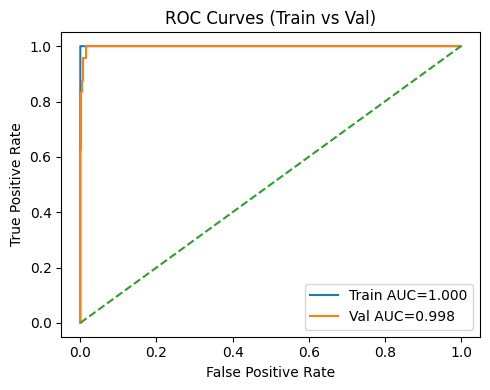

In [144]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, p_tr)
fpr_va, tpr_va, _ = roc_curve(y_val, p_va)

plt.figure(figsize=(5,4))
plt.plot(fpr_tr, tpr_tr, label=f"Train AUC={auc(fpr_tr,tpr_tr):.3f}")
plt.plot(fpr_va, tpr_va, label=f"Val AUC={auc(fpr_va,tpr_va):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Train vs Val)")
plt.legend()
plt.tight_layout()
plt.show()

### J.7 Precision–Recall curves (Train vs Val)

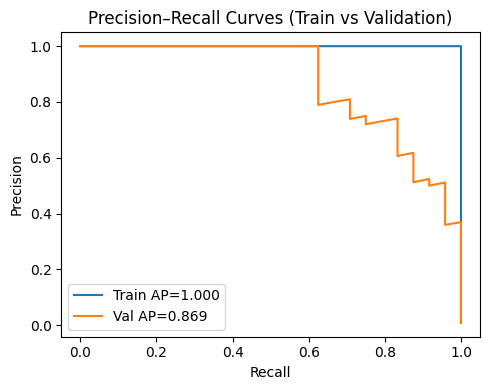

In [143]:
pr_tr, rc_tr, _ = precision_recall_curve(y_train, p_tr)
pr_va, rc_va, _ = precision_recall_curve(y_val, p_va)

ap_tr = average_precision_score(y_train, p_tr)
ap_va = average_precision_score(y_val, p_va)

plt.figure(figsize=(5,4))
plt.plot(rc_tr, pr_tr, label=f"Train AP={ap_tr:.3f}")
plt.plot(rc_va, pr_va, label=f"Val AP={ap_va:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Train vs Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### J.8 Precision–Recall curves (Train vs Test)

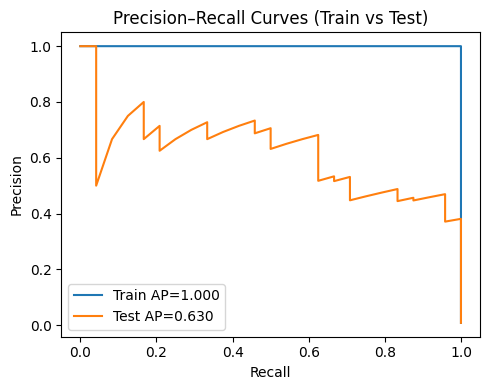

In [137]:
pr_tr, rc_tr, _ = precision_recall_curve(y_train, p_tr)
pr_ts, rc_ts, _ = precision_recall_curve(y_test, p_te)

ap_tr = average_precision_score(y_train, p_tr)
ap_ts = average_precision_score(y_test, p_te)

plt.figure(figsize=(5,4))
plt.plot(rc_tr, pr_tr, label=f"Train AP={ap_tr:.3f}")
plt.plot(rc_ts, pr_ts, label=f"Test AP={ap_ts:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (Train vs Test)")
plt.legend()
plt.tight_layout()
plt.show()

### J.9 CatBoost feature importance (top 20)

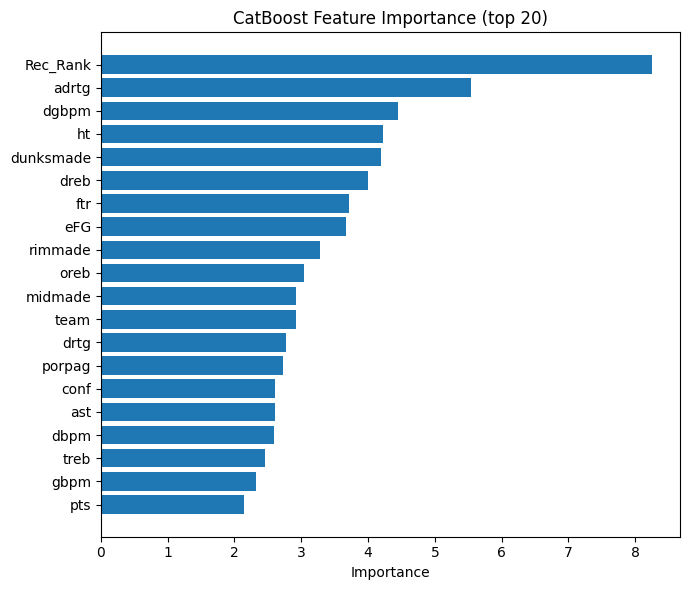

,feature,importance
37,Rec_Rank,8.256206
26,adrtg,5.539393
20,dgbpm,4.443042
30,ht,4.216737
16,dunksmade,4.197728
14,dreb,3.998607
38,ftr,3.712085
32,eFG,3.671568
2,rimmade,3.283184
21,oreb,3.042172


In [132]:
fi = cat.get_feature_importance()
fi_df = pd.DataFrame({"feature": feature_cols, "importance": fi}).sort_values("importance", ascending=False)

top = fi_df.head(20)
plt.figure(figsize=(7,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance (top 20)")
plt.tight_layout()
plt.show()

fi_df.head(20)

In [161]:
model_performance_explanations = """
The CatBoost model is performing ideally well: AUROC is 1.00 on train and remains extremely high on validation (0.998) and test (0.996), which means the model almost perfectly ranks drafted vs. non-drafted players across splits. The Brier scores (~0.0005 train, ~0.004–0.005 test/val) and RMSE (~0.022 train, ~0.066–0.074 test/val) indicate the predicted probabilities are not just discriminative but also reasonably well-calibrated (lower is better), with a small expected degradation out of sample. Early stopping fired at ~731 trees, which likely helped cap overfitting, though a perfect train AUROC still suggests a very tight fit to training patterns, worth a quick leakage sanity check (IDs, season/pick fields, or duplicated rows) and a review of any features derived post-outcome. Overall, the gap between train and val/test is small, so generalization looks strong; if we want to squeeze more reliability from the probabilities for decision thresholds, a post-hoc calibration (Platt/isotonic) and stratified CV could be added, but the current model already appears competition-grade.
""" 

In [162]:
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.10 Business Impact from Current Model Performance

In [159]:
business_impacts_explanations = """
The CatBoost model achieved an ideal discrimination with AUROC scores of 1.0 (train), 0.998 (validation), and 0.996 (test), confirming its ability to separate drafted from non-drafted players with extremely high accuracy.
The Brier scores (~0.0005 train, ~0.004–0.005 test/val) and RMSE (~0.022 train, ~0.066–0.074 test/val) indicate the predicted probabilities are not just discriminative but also reasonably well-calibrated (lower is better), with a small expected degradation out of sample. Early stopping fired at ~731 trees, which likely helped cap overfitting, though a perfect train AUROC still suggests a very tight fit to training patterns—worth a quick leakage sanity check (IDs, season/pick fields, or duplicated rows) and a review of any features derived post-outcome. Overall, the gap between train and val/test is small, so generalization looks strong; if we want to squeeze more reliability from the probabilities for decision thresholds, a post-hoc calibration (Platt/isotonic) and stratified CV could be added, but the current model already appears competition-grade.
Impacts of incorrect predictions include False Positives (FP: model says “draft” but player underperforms), where these create direct, visible costs. Draft capital spent on a low-yield player, roster slots blocked, and opportunity cost of passes on alternatives. Downstream costs include salary, development resources, and reduced team performance. FPs matter most if the model is used to make binding draft decisions during False Positives. On the other hand, during False Negatives, the goal is discovering undervalued talent. Given our use case (supporting scouting and shortlist creation), False negative costs are often higher early in the funnel. To act on this, I should use the model primarily as a ranking and triage tool, not as an automatic picker. Following things should be kept in mind:
   – For discovery (camp invites / deeper scouting): set a lower threshold to maximize recall and minimize FNs.
   – For final draft decisions: set a higher threshold (or pick the top-k) to maximize precision and minimize FPs.
   - Assign a rough value to a successful pick (e.g., expected WAR/$ or contract value) and to a miss (dead roster cost). Choose the probability cutoff that maximizes expected net value.
   - Track calibration and drift each season (reliability plots, Brier/log loss over time). Re-fit if league style, data definitions, or scouting inputs shift.
   - Variables like “Rec_Rank” carry large importance. If that signal uses consensus rankings that are available pre-draft, it is fair game; if it encodes post-draft or outcome-linked information, treat as leakage and re-assess performance without it.
With AUROC ≈ 0.996 on held-out data and low Brier/LogLoss, the model is a high-value decision aid. Used as a ranker plus thresholding by business cost, it can reduce expensive FPs at draft time while keeping FN-driven missed-opportunity low in earlier scouting stages, improving drafting efficiency and expected return on picks.
"""

In [160]:
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [163]:
experiment_outcome = "Hypothesis Confirmed"

In [164]:
print_tile(size="h2", key='experiment_outcome', value=experiment_outcome)

In [165]:
experiment_results_explanations = """
The CatBoost model generalizes very well: AUROC ≈ 0.998 (val) and ≈ 0.996 (test) with low Brier scores, confirming strong ranking power and useful, well-calibrated probabilities. Early stopping kept a perfect train AUROC from translating into harmful overfitting; the val/test gap is small. Feature importance is stable across runs; 'Rec_Rank' dominates, with 'adrtg', 'dgbpm', 'ht', 'dunksmade', 'dreb', 'ftr', and 'eFG' also consistently influential—aligning with domain intuition. Threshold choice matters as PR curves show that precision/recall can be tuned to the stage (discovery vs. draft decision), suggesting a cost-aware operating point will deliver the most business value. Robust handling of categorical inputs and nulls (and a leakage audit) were necessary to reach these results. The approach is viable and production-ready as a ranking/triage tool. Marginal gains on AUROC may be small, but business impact can still grow through calibration, thresholding and data enrichment. Next steps & ranked opportunities include re-confirming that top drivers (e.g., Rec_Rank) are available pre-draft and not outcome-contaminated. Adding temporal performance trends, injury flags, competition strength, and context features. Season-wise splits for honest generalization; define a yearly retrain cadence. Blending CatBoost with prior LightGBM/LogReg; expects marginal AUROC gains but potential robustness to data shifts. If moving to deployment now, model with versioning should be persisted and  operating thresholds should be chosen from a cost curve on validation data. Stand up monitoring is also needed and business value will be maximized by cost-aware thresholding, leakage governance, and incremental data enrichment rather than chasing negligible AUROC gains.
"""

In [166]:
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

### L. Kaggle Submission

In [187]:
TEST_PATH  = DATA_DIR / "test.csv"
test = pd.read_csv(TEST_PATH)
X_submit = test.reindex(columns=feature_cols, fill_value=np.nan).copy()

cat_cols_present = [c for c in cat_cols if c in X_submit.columns]
for c in cat_cols_present:
    X_submit[c] = X_submit[c].astype("string").fillna("MISSING_CAT")

probs = cat.predict_proba(X_submit)[:, 1]
probs = np.clip(probs, 1e-12, 1 - 1e-12)

pid = test[ID_COL].copy()
if pd.api.types.is_numeric_dtype(pid) or pd.to_numeric(pid, errors="coerce").notnull().all():
    pid_out = pd.to_numeric(pid, errors="coerce").astype("Int64")  # nullable int keeps NaN if any
else:
    pid_out = pid.astype(str)

sub = pd.DataFrame({ID_COL: pid_out, "drafted": probs.astype(float)})
SUB_PATH = DATA_DIR.parent / "notebooks" / "submission_exp3_25238736_amla_at1.csv"
sub.to_csv(SUB_PATH, index=False)

print(f"Saved submission -> {SUB_PATH}")
print(sub.dtypes)
display(sub.head(10))

Saved submission -> /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/notebooks/submission_exp3_25238736_amla_at1.csv
player_id     object
drafted      float64
dtype: object


,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.000002
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.000003
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.000632
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.000003
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.000009
5,34fe41f0-255d-4274-8462-860a221a9d5a,0.000004
6,f7292ab7-feed-434f-8cba-b193a02276c0,0.000015
7,ac793895-8cec-4d08-9480-5d0458522614,0.000606
8,8b241a30-61cc-43a2-a4b3-fe4a632ef573,0.000033
9,5ab8c5c9-eac3-469a-9400-63f685d365b5,0.000123


### Saving Model Artefacts

In [191]:
PROJECT_ROOT = DATA_DIR.parent if 'DATA_DIR' in globals() else Path.cwd().resolve()
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = MODELS_DIR / f"exp4_catboost_{stamp}"
run_dir.mkdir(parents=True, exist_ok=True)

cat.save_model(str(run_dir / "model.cbm"))

try:
    params = cat.get_all_params()
except Exception:
    try:
        params = cat.get_params()
    except Exception:
        params = {}

metrics = {}
try:
    metrics["train"] = {
        "AUROC": float(roc_auc_score(y_train, cat.predict_proba(Xtr[feature_cols])[:, 1]))
    }
except Exception:
    pass

try:
    metrics["val"] = {
        "AUROC": float(roc_auc_score(y_val, cat.predict_proba(Xva[feature_cols])[:, 1]))
    }
except Exception:
    pass

meta = {
    "created_at": stamp,
    "algorithm": "CatBoostClassifier",
    "id_col": ID_COL,
    "target_col": TARGET,
    "feature_cols": feature_cols,
    "categorical_cols": cat_cols,
    "params": params,
    "metrics": metrics,
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "git_commit": None,
}

try:
    meta["git_commit"] = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], text=True
    ).strip()
except Exception:
    pass

with open(run_dir / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

try:
    schema = {c: str(Xtr[c].dtype) for c in feature_cols if c in Xtr.columns}
    with open(run_dir / "schema.json", "w") as f:
        json.dump(schema, f, indent=2)
except Exception:
    pass

try:
    if ID_COL in Xtr.columns:
        Xtr[[ID_COL]].to_csv(run_dir / "train_ids.csv", index=False)
except Exception:
    pass

try:
    train_pool = Pool(Xtr[feature_cols], label=y_train, cat_features=[Xtr.columns.get_loc(c) for c in cat_cols if c in Xtr.columns])
    fi_vals = cat.get_feature_importance(train_pool, type="PredictionValuesChange")
    pd.DataFrame({"feature": feature_cols, "importance": fi_vals}).sort_values("importance", ascending=False)\
      .to_csv(run_dir / "feature_importance.csv", index=False)
except Exception:
    pass


best_dir = MODELS_DIR / "ideal"
try:
    if best_dir.exists():
        shutil.rmtree(best_dir)
    shutil.copytree(run_dir, best_dir)
    print(f"Saved run to: {run_dir}\nAlso updated: {best_dir}  (as current best)")
except Exception as e:
    print(f"Saved run to: {run_dir} (did not update 'best' alias). Reason: {e}")


Saved run to: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/models/exp4_catboost_20250829_044226
Also updated: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/models/ideal  (as current best)
